In [1]:
import os 
from pathlib import Path
import numpy as np
import glob
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
os.chdir(Path('/home/globc/garcia/'))

from scenarIA.src.utils.plotutils import plot_mean_std_simulations
from scenarIA.src.utils.settings import DATASET_DIR, GRAPHS_DIR

/softs/Anaconda/2024.02-1/envs/gloenv_py3.11/lib/python3.12/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


<xarray.Dataset> Size: 19MB
Dimensions:    (time: 86, longitude: 144, latitude: 96)
Coordinates:
  * longitude  (longitude) float64 1kB 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * latitude   (latitude) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * time       (time) int64 688B 2015 2016 2017 2018 ... 2097 2098 2099 2100
Data variables:
    CO2        (time) float64 688B ...
    SO2        (time, latitude, longitude) float64 10MB ...
    CH4        (time) float64 688B ...
    BC         (time, latitude, longitude) float64 10MB ...


ValueError: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>

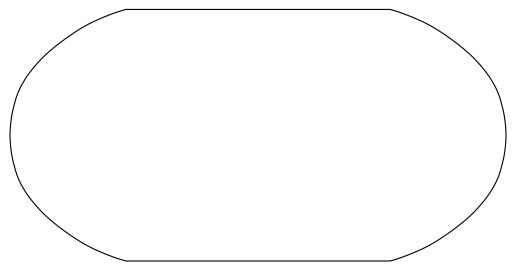

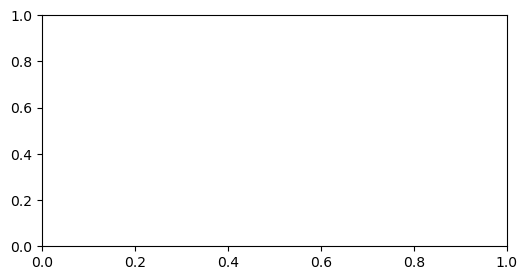

In [26]:
for simu in ['ssp126', 'ssp245', 'ssp370', 'ssp585']:

    dataset_dir = DATASET_DIR / 'MPI-ESM1-2-LR/annual'
    
    inputs = xr.open_dataset(dataset_dir / f'inputs_{simu}_regrid2.nc')
    plt.subplot(projection=ccrs.Robinson())
    cs = inputs["SO2"].sel(time=slice('2080', '2100')).mean('time').plot(transform=ccrs.PlateCarree(), add_colorbar=True, 
                                                                         norm=colors.LogNorm(1e-15, 1e-9, clip=True),
                                                                        cbar_kwargs= {'shrink':0.6})
    plt.gca().coastlines()
    plt.gca().set_title(f'{simu} 2080-2100')
    plt.colorbar(cs, ax=ax, shrink=0.7)
    plt.savefig(f'/gpfs-calypso/scratch/globc/garcia/scenarIA/graphs/data/Input4MIPs/SO2_2080_2100_maps_{simu}.png')
    plt.close()

<xarray.Dataset> Size: 25MB
Dimensions:  (time: 86, lat: 96, lon: 192)
Coordinates:
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * time     (time) datetime64[ns] 688B 2015-01-01 2016-01-01 ... 2100-01-01
Data variables:
    SO2      (time, lat, lon) float64 13MB ...
    BC       (time, lat, lon) float64 13MB ...
    CO2      (time) float64 688B ...
    CH4      (time) float64 688B ...
Attributes:
    regrid_method:  conservative


TypeError: No numeric data to plot.

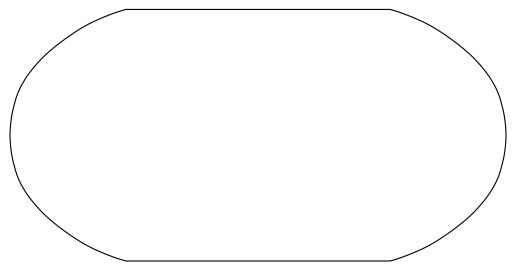

In [4]:
for simu in ['ssp126', 'ssp245', 'ssp370', 'ssp585']:

    dataset_dir = DATASET_DIR / 'MPI-ESM1-2-LR/annual'
    
    inputs = xr.open_dataset(dataset_dir / f'inputs_{simu}_regrid2.nc')
    print(inputs)
    plt.subplot(projection=ccrs.Robinson())
    cs = inputs["CO2"].sel(time=slice('2080', '2100')).mean('time').plot(transform=ccrs.PlateCarree(), add_colorbar=True,
                                                                        cbar_kwargs= {'shrink':0.6})
    plt.gca().coastlines()
    plt.gca().set_title(f'{simu} 2080-2100')
    plt.colorbar(cs, ax=ax, shrink=0.7)
    #plt.savefig(f'/gpfs-calypso/scratch/globc/garcia/scenarIA/graphs/data/Input4MIPs/BC_2080_2100_maps_{simu}.png')
    #plt.close()

[<xarray.DataArray 'longitude' ()> Size: 8B
array(0.), <xarray.DataArray 'longitude' ()> Size: 8B
array(357.5), <xarray.DataArray 'latitude' ()> Size: 8B
array(-90.), <xarray.DataArray 'latitude' ()> Size: 8B
array(90.)]


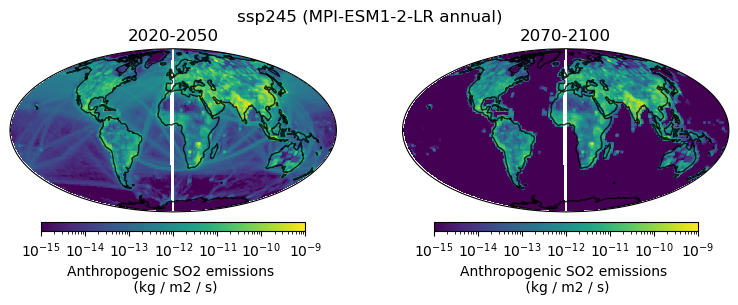

In [8]:
ds = inputs['SO2']
periods = [['2020','2050'], ['2070','2100']]
lonmin, lonmax, latmin, latmax = ds.longitude.min(), ds.longitude.max(), ds.latitude.min(), ds.latitude.max()
extent = [lonmin, lonmax, latmin, latmax]
fig, axes = plt.subplots(1, 2, figsize=(8,3), subplot_kw={'projection': ccrs.Mollweide()})
    #vmin, vmax = y_true.min(), y_true.max()
print(extent)

for i, period in enumerate(periods):
    start = period[0]
    end = period[1]
    #cs = ds.sel(time=slice(start, end)).mean('time').plot(transform=ccrs.PlateCarree(), add_colorbar=False, norm=colors.LogNorm(1e-15, 1e-9, clip=True))
    data = ds.sel(time=slice(start, end)).mean('time').values
    data = np.flip(data, axis=0)
    ax = axes[i]
    cs = ax.imshow(data,
             cmap='viridis',
             extent=extent,
             transform=ccrs.PlateCarree(),
             norm=colors.LogNorm(1e-15, 1e-9, clip=True)
            )

    ax.set_global()
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1, zorder=10, alpha=0.8)
    ax.set_title(f'{start}-{end}')

    cbar = fig.colorbar(cs, ax=ax, shrink=0.7,
                    orientation='horizontal',
                    location='bottom',
                    pad=0.05,
                    aspect=30, 
                    label=f'Anthropogenic SO2 emissions \n (kg / m2 / s)')
    
plt.suptitle(title)
plt.tight_layout()


In [28]:
outputs = xr.open_dataset(dataset_dir / f'outputs_{simu_test}.nc')
clim = xr.open_dataset(dataset_dir / f'outputs_piControl.nc').mean('member')
clim = clim.sel(time=slice('1850', '2250')).mean('time')
outputs = outputs - clim

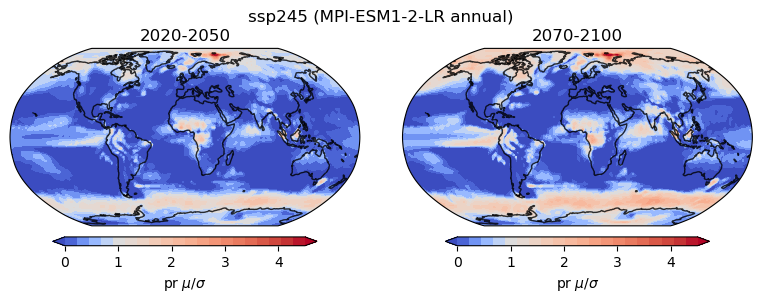

In [112]:
var = 'pr'
ds = outputs[var]
periods = [['2020','2050'], ['2070','2100']]
vmin = 0
vmax = 4.5


fig, axes = plt.subplots(1, 2, figsize=(8,3), subplot_kw={'projection': ccrs.Robinson() })


for i, period in enumerate(periods):
    start = period[0]
    end = period[1]
    data = ds.sel(time=slice(start, end))
    ratio = data.mean('member') / data.std('member')
    ratio = ratio.mean('time')
    ax = axes[i]
    cs = ax.contourf(ratio,
             cmap='coolwarm',
             extent=[0., 360., -90., 90.],
             transform=ccrs.PlateCarree(),
            levels=np.linspace(vmin, vmax, 21),
            extend='both',
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=1., vmax=vmax)
            )

    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1, zorder=10, alpha=0.8)
    ax.set_title(f'{start}-{end}')

    cbar = fig.colorbar(cs, ax=ax, shrink=0.7,
                    orientation='horizontal',
                    location='bottom',
                    pad=0.05,
                    aspect=30, 
                    label=fr'{var} $\mu/\sigma$')
    
    cbar.set_ticks([0, 1, 2, 3, 4])
    cbar.set_ticklabels([str(i) for i in [0, 1, 2, 3, 4]])
    #cbar.set_ticks(np.linspace(vmin, vmax, 7))
    #cbar.set_ticklabels([str(round(int(i), 1)) for i in np.linspace(vmin, vmax, 7)])
plt.suptitle(title)
plt.tight_layout()